# Prédiction du prix des maisons aux États-Unis

## Introduction

L’estimation du prix d’un bien immobilier constitue un enjeu important pour de nombreux acteurs du marché, qu’il s’agisse d’acheteurs, de vendeurs, d’agences ou d’investisseurs. Le prix d’une maison dépend de nombreux facteurs, tels que sa surface habitable, la taille du terrain, le nombre de chambres et de salles de bain, la qualité du bien, sa localisation ou encore certaines caractéristiques premium comme la vue ou la proximité de l’eau.

Dans ce projet, l’objectif est de construire un modèle de machine learning capable de prédire le prix de vente d’une maison à partir de ses caractéristiques. Le travail suit une démarche complète de data science : exploration et nettoyage des données, analyse exploratoire, feature engineering, préparation des variables, modélisation, validation croisée et analyse de l’overfitting.

L’intérêt de ce projet est double. D’une part, il permet de mieux comprendre quels sont les facteurs les plus liés au prix immobilier. D’autre part, il offre un cadre concret pour comparer plusieurs approches de modélisation et identifier le modèle le plus performant et le plus robuste.

## Problématique

Peut-on prédire de manière fiable le prix d’un bien immobilier à partir de ses caractéristiques structurelles, de sa localisation et de variables de standing, tout en identifiant le modèle offrant le meilleur compromis entre performance prédictive, robustesse et capacité de généralisation ?

## Objectifs du projet

- Comprendre la structure et la qualité du dataset
- Identifier les variables les plus pertinentes pour expliquer le prix
- Construire de nouvelles features utiles à la modélisation
- Comparer plusieurs modèles de régression
- Évaluer les performances sur un jeu de test et par validation croisée
- Sélectionner le modèle final le plus pertinent

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## Initialisation de l’environnement de travail

Cette cellule importe les bibliothèques nécessaires à l’ensemble du projet. Les librairies `numpy` et `pandas` sont utilisées pour la manipulation et l’analyse des données, tandis que `matplotlib` et `seaborn` servent à la visualisation.

Les outils de `scikit-learn` sont également chargés afin de préparer la phase de modélisation : séparation train/test, validation croisée, pipelines de prétraitement, encodage des variables catégorielles, standardisation des variables numériques, gestion des valeurs manquantes, ainsi que plusieurs modèles de régression à comparer.

Enfin, quelques paramètres d’affichage sont définis pour améliorer la lisibilité des tableaux et des graphiques dans le notebook.

In [2]:
df = pd.read_csv("USA Housing Dataset.csv")

print(f"Shape: {df.shape}")
display(df.head())

Shape: (4140, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,"376,000.00",3.00,2.00,1340,1384,3.00,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,"800,000.00",4.00,3.25,3540,159430,2.00,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,"2,238,888.00",5.00,6.50,7270,130017,2.00,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,"324,000.00",3.00,2.25,998,904,2.00,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,"549,900.00",5.00,2.75,3060,7015,1.00,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


## Chargement initial des données

Le dataset est chargé dans un DataFrame pandas afin de lancer l’analyse exploratoire et la préparation des données. La première vérification montre que le jeu de données contient **4140 observations** et **18 variables**.

L’aperçu des premières lignes permet d’identifier plusieurs familles de variables :  
- des variables numériques décrivant les dimensions du bien (`sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`) ;
- des variables structurelles (`bedrooms`, `bathrooms`, `floors`) ;
- des variables de standing ou de qualité (`waterfront`, `view`, `condition`) ;
- des variables temporelles (`date`, `yr_built`, `yr_renovated`) ;
- des variables de localisation (`street`, `city`, `statezip`, `country`).


In [3]:
print("Colonnes :")
print(df.columns.tolist())
print("Types :")
display(df.dtypes.to_frame("dtype"))
print("Valeurs manquantes :")
display(df.isnull().sum().to_frame("missing"))
print(f"Doublons exacts : {df.duplicated().sum()}")

Colonnes :
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']
Types :


,dtype
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


Valeurs manquantes :


,missing
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


Doublons exacts : 0


## Inspection de la structure du dataset

L’inspection initiale du dataset montre qu’il contient **18 variables** couvrant plusieurs dimensions pertinentes pour la prédiction du prix immobilier : caractéristiques physiques du bien, qualité, temporalité et localisation.

Les types de données indiquent que la majorité des variables sont numériques, tandis que `date`, `street`, `city`, `statezip` et `country` sont lues comme des variables de type `object`. Parmi elles, `date` devra être convertie en format temporel pour être exploitée correctement, tandis que certaines variables catégorielles comme `city` ou `statezip` pourront être utiles pour la modélisation.

Aucune valeur manquante explicite (`NaN`) n’est observée dans le dataset, ce qui constitue un point positif pour la qualité initiale des données. De même, aucun doublon exact n’a été détecté. Le jeu de données apparaît donc propre sur le plan technique.

Néanmoins, cette première inspection ne suffit pas à conclure que les données sont entièrement prêtes pour la modélisation. Il reste nécessaire de vérifier la présence de valeurs incohérentes, de faux manquants codés implicitement, ainsi que la pertinence réelle de certaines colonnes comme `street` ou `country`.

In [4]:
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    print(f"\nColonne : {col}")
    print("Chaînes vides :", (df[col] == "").sum())
    print("Espaces seulement :", df[col].astype(str).str.strip().eq("").sum())


Colonne : date
Chaînes vides : 0
Espaces seulement : 0

Colonne : street
Chaînes vides : 0
Espaces seulement : 0

Colonne : city
Chaînes vides : 0
Espaces seulement : 0

Colonne : statezip
Chaînes vides : 0
Espaces seulement : 0

Colonne : country
Chaînes vides : 0
Espaces seulement : 0


In [5]:
fake_missing = ["unknown", "Unknown", "UNKNOWN", "na", "NA", "null", "NULL", "?", "none", "None"]

for col in text_cols:
    print(f"\nColonne : {col}")
    print(df[col].isin(fake_missing).sum())


Colonne : date
0

Colonne : street
0

Colonne : city
0

Colonne : statezip
0

Colonne : country
0


In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col} : {zero_count} zéros")

price : 49 zéros
bedrooms : 2 zéros
bathrooms : 2 zéros
sqft_living : 0 zéros
sqft_lot : 0 zéros
floors : 0 zéros
waterfront : 4109 zéros
view : 3722 zéros
condition : 0 zéros
sqft_above : 0 zéros
sqft_basement : 2476 zéros
yr_built : 0 zéros
yr_renovated : 2462 zéros


In [ ]:
df['country'].nunique()

1

In [11]:
df["street"].nunique()

4079

## Vérification des valeurs particulières et des variables catégorielles

L’analyse complémentaire montre qu’aucune colonne textuelle ne contient de chaînes vides, d’espaces seuls ou de faux manquants tels que `unknown`, `null` ou `?`... Les variables textuelles apparaissent donc propres à ce stade.

En revanche, l’examen des zéros dans les variables numériques met en évidence deux situations distinctes. Certaines valeurs nulles semblent incohérentes dans le contexte métier, notamment pour `price`, `bedrooms` et `bathrooms`, et devront être traitées lors du nettoyage. À l’inverse, d’autres zéros sont plausibles et informatifs, comme pour `waterfront`, `view`, `sqft_basement` ou `yr_renovated`, où ils traduisent vraisemblablement une absence de caractéristique plutôt qu’une erreur.

Enfin, l’analyse de cardinalité confirme que `country` est constante (`nunique = 1`) et n’apporte donc aucune information utile. La variable `street`, avec `4079` valeurs uniques pour `4140` observations, présente une cardinalité beaucoup trop élevée pour un encodage standard et se rapproche d’un identifiant quasi unique. Ces deux colonnes seront donc supprimées dans la suite du projet.

In [12]:
clean_df = df.copy()

clean_df = clean_df[clean_df["price"] > 0]
clean_df = clean_df[clean_df["bedrooms"] > 0]
clean_df = clean_df[clean_df["bathrooms"] > 0]

clean_df = clean_df.drop(columns=["country", "street"])

print(f"Shape après nettoyage de base : {clean_df.shape}")

Shape après nettoyage de base : (4089, 16)


In [13]:
clean_df["date"] = pd.to_datetime(clean_df["date"])

In [14]:
clean_df.dtypes

date             datetime64[ns]
price                   float64
bedrooms                float64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
city                     object
statezip                 object
dtype: object

In [15]:
clean_df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
price,"4,089.00","559,376.29","583,975.35","7,800.00","325,000.00","464,500.00","660,000.00","26,590,000.00"
bedrooms,"4,089.00",3.40,0.90,1.00,3.00,3.00,4.00,8.00
bathrooms,"4,089.00",2.16,0.78,0.75,1.75,2.25,2.50,6.75
sqft_living,"4,089.00","2,135.05",948.52,370.00,"1,460.00","1,980.00","2,610.00","10,040.00"
sqft_lot,"4,089.00","14,675.77","35,973.12",638.00,"5,000.00","7,665.00","10,945.00","1,074,218.00"
floors,"4,089.00",1.51,0.53,1.00,1.00,1.50,2.00,3.50
waterfront,"4,089.00",0.01,0.08,0.00,0.00,0.00,0.00,1.00
view,"4,089.00",0.24,0.78,0.00,0.00,0.00,0.00,4.00
condition,"4,089.00",3.45,0.68,1.00,3.00,3.00,4.00,5.00
sqft_above,"4,089.00","1,824.76",851.51,370.00,"1,190.00","1,600.00","2,300.00","7,680.00"


## Statistiques descriptives initiales

Les statistiques descriptives confirment que la variable cible `price` présente une forte dispersion et une asymétrie à droite. En effet, la moyenne (**559 376**) est nettement supérieure à la médiane (**464 500**), ce qui indique que quelques biens très chers tirent la distribution vers le haut. Le maximum observé (**26 590 000**) suggère également la présence de valeurs extrêmes, probablement associées à des biens de luxe ou atypiques.

Les variables structurelles comme `bedrooms`, `bathrooms`, `sqft_living` et `floors` paraissent globalement cohérentes. Les médianes observées correspondent à des logements résidentiels classiques, tandis que les valeurs maximales traduisent l’existence de biens plus rares ou haut de gamme, sans révéler d’anomalie évidente à ce stade.

Certaines variables présentent cependant une distribution très asymétrique, notamment `sqft_lot`, `sqft_basement` et `yr_renovated`. Pour `sqft_lot`, l’écart important entre les quartiles et le maximum indique la présence de terrains exceptionnellement grands. Pour `sqft_basement`, la médiane nulle montre qu’une grande partie des biens ne possède pas de sous-sol. De même, `yr_renovated` présente une médiane égale à zéro, ce qui suggère qu’un grand nombre de maisons n’ont jamais été rénovées. Ces deux variables devront donc être interprétées avec précaution.

Enfin, les variables `waterfront` et `view` apparaissent très déséquilibrées. La majorité des biens ne sont pas situés en bord de l’eau et ne disposent pas d’une vue remarquable, ce qui est cohérent avec le marché immobilier résidentiel. Malgré leur rareté, ces caractéristiques pourraient avoir un impact important sur le prix des biens.

In [16]:
cols_to_check = ["price", "sqft_living", "sqft_lot", "bedrooms", "bathrooms"]
def detect_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series < lower_bound) | (series > upper_bound)
df_out = clean_df.copy()

for col in cols_to_check:
    df_out[f'outlier_{col}'] = detect_iqr(df_out[col])

for col in cols_to_check:
    print(f'{col} :' , df_out[f'outlier_{col}'].sum(), 'outliers')

outlier_cols = [f"outlier_{col}" for col in cols_to_check]
df_out["n_outliers"] = df_out[outlier_cols].sum(axis=1)

# Voir les lignes qui sont extrêmes sur plusieurs variables en même temps
multi_outliers = df_out[df_out["n_outliers"] >= 2]

print("Nombre de lignes extrêmes sur au moins 2 variables :", multi_outliers.shape[0])

# Afficher quelques exemples
cols_display = cols_to_check + outlier_cols + ["n_outliers"]
multi_outliers[cols_display].sort_values("n_outliers", ascending=False).head(10)

price : 215 outliers
sqft_living : 117 outliers
sqft_lot : 480 outliers
bedrooms : 103 outliers
bathrooms : 115 outliers
Nombre de lignes extrêmes sur au moins 2 variables : 167


,price,sqft_living,sqft_lot,bedrooms,bathrooms,outlier_price,outlier_sqft_living,outlier_sqft_lot,outlier_bedrooms,outlier_bathrooms,n_outliers
2271,"1,600,000.00",6050,230652,6.00,5.00,True,True,True,True,True,5
2,"2,238,888.00",7270,130017,5.00,6.50,True,True,True,False,True,4
3099,"1,820,000.00",6640,53330,4.00,4.50,True,True,True,False,True,4
1451,"2,005,000.00",3810,28176,6.00,4.50,True,False,True,True,True,4
1107,"3,100,000.00",6980,15682,6.00,4.25,True,True,False,True,True,4
1545,"1,415,000.00",4670,43950,4.00,5.25,True,True,True,False,True,4
1826,"7,062,500.00",10040,37325,5.00,4.50,True,True,True,False,True,4
11,"1,225,000.00",5420,101930,4.00,4.50,True,True,True,False,True,4
1868,"2,888,000.00",8670,64033,5.00,6.25,True,True,True,False,True,4
842,"1,680,000.00",5584,68257,4.00,4.25,True,True,True,False,True,4


In [17]:
multi_outliers = df_out[(df_out["n_outliers"] == 1)]

In [18]:
multi_outliers[cols_display].sort_values("n_outliers", ascending=False).head(10)

,price,sqft_living,sqft_lot,bedrooms,bathrooms,outlier_price,outlier_sqft_living,outlier_sqft_lot,outlier_bedrooms,outlier_bathrooms,n_outliers
1,"800,000.00",3540,159430,4.00,3.25,False,False,True,False,False,1
2792,"599,000.00",2730,22572,5.00,2.75,False,False,True,False,False,1
2814,"790,000.00",3190,31450,4.00,3.50,False,False,True,False,False,1
2821,"1,200,000.00",3990,13470,4.00,1.75,True,False,False,False,False,1
2824,"2,300,000.00",4250,8570,4.00,3.25,True,False,False,False,False,1
2828,"597,326.00",3570,8250,4.00,4.00,False,False,False,False,True,1
2841,"356,000.00",2020,48693,4.00,2.00,False,False,True,False,False,1
2872,"860,000.00",4500,9648,5.00,3.25,False,True,False,False,False,1
2875,"305,000.00",1900,8240,6.00,2.00,False,False,False,True,False,1
2877,"1,355,000.00",2680,4775,3.00,1.50,True,False,False,False,False,1


## Détection des observations extrêmes

Afin d’analyser les valeurs extrêmes de manière plus rigoureuse, une détection des outliers a été réalisée sur plusieurs variables clés du dataset : `price`, `sqft_living`, `sqft_lot`, `bedrooms` et `bathrooms`. La méthode utilisée repose sur la règle de l’écart interquartile (IQR), qui considère comme atypiques les observations situées en dehors de l’intervalle \([Q1 - 1.5 * IQR,\; Q3 + 1.5 * IQR]\).

Pour chaque variable, une colonne booléenne a été créée afin d’indiquer si l’observation est extrême ou non. Un score `n_outliers` a ensuite été calculé pour compter, ligne par ligne, le nombre de variables sur lesquelles chaque bien est considéré comme atypique.

Cette approche permet de distinguer les valeurs extrêmes isolées des biens qui apparaissent atypiques sur plusieurs dimensions à la fois. Dans le contexte immobilier, cette distinction est importante : une maison très chère, très grande et disposant de nombreuses chambres ou salles de bain peut être statistiquement extrême sans être incohérente. L’objectif de cette étape est donc moins de supprimer automatiquement les outliers que de comprendre s’ils correspondent à de véritables anomalies ou à des biens exceptionnellement haut de gamme.

In [21]:
clean_df['yr_renovated'].nunique()

59

In [19]:
(clean_df['yr_renovated'] == 0).sum()

2433

In [22]:
clean_df['sqft_basement'].nunique()

205

In [23]:
(clean_df['sqft_basement'] == 0).sum()

2447

In [24]:
fe_df = clean_df.copy()

fe_df["is_renovated"] = (fe_df["yr_renovated"] > 0).astype(int)
fe_df["has_basement"] = (fe_df["sqft_basement"] > 0).astype(int)

## Interprétation de `yr_renovated` et `sqft_basement`

L’analyse de `yr_renovated` montre que cette variable possède **59 valeurs distinctes**, mais qu’une grande partie des observations prend la valeur `0` (`2433` lignes). Cela indique que `0` ne correspond pas à une année réelle, mais vraisemblablement à l’absence de rénovation. La variable brute mélange donc deux informations : le fait d’avoir été rénové ou non, et l’année de rénovation lorsque celle-ci existe. Pour cette raison, une variable binaire `is_renovated` a été créée afin de capturer plus directement cette information.

De manière similaire, `sqft_basement` possède **205 valeurs distinctes**, avec `2447` observations égales à `0`. Cette structure suggère que la valeur nulle correspond à l’absence de sous-sol, tandis que les valeurs positives décrivent la taille du sous-sol lorsqu’il existe. La création d’une variable binaire `has_basement` permet donc de distinguer explicitement la présence d’un sous-sol de sa surface.

Ces deux transformations relèvent d’une logique de feature engineering : lorsqu’une variable contient une forte proportion de zéros correspondant à une absence de caractéristique plutôt qu’à une valeur numérique ordinaire, il peut être pertinent de créer une variable binaire complémentaire pour améliorer l’interprétabilité et potentiellement la performance du modèle.

In [25]:
fe_df["sale_year"] = fe_df["date"].dt.year
fe_df["sale_month"] = fe_df["date"].dt.month
fe_df["sale_day"] = fe_df["date"].dt.day

fe_df["home_age"] = fe_df["sale_year"] - fe_df["yr_built"]
fe_df["sqft_ratio"] = fe_df["sqft_living"] / fe_df["sqft_lot"].clip(lower=1)
fe_df["total_rooms"] = fe_df["bedrooms"] + fe_df["bathrooms"]

# la date brute n'est pas gardée telle quelle pour la modélisation
fe_df = fe_df.drop(columns=["date"])

fe_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,is_renovated,has_basement,sale_year,sale_month,sale_day,home_age,sqft_ratio,total_rooms
0,"376,000.00",3.00,2.00,1340,1384,3.00,0,0,3,1340,0,2008,0,Seattle,WA 98103,0,0,2014,5,9,6,0.97,5.00
1,"800,000.00",4.00,3.25,3540,159430,2.00,0,0,3,3540,0,2007,0,Carnation,WA 98014,0,0,2014,5,9,7,0.02,7.25
2,"2,238,888.00",5.00,6.50,7270,130017,2.00,0,0,3,6420,850,2010,0,Issaquah,WA 98029,0,1,2014,5,9,4,0.06,11.50
3,"324,000.00",3.00,2.25,998,904,2.00,0,0,3,798,200,2007,0,Seattle,WA 98117,0,1,2014,5,9,7,1.10,5.25
4,"549,900.00",5.00,2.75,3060,7015,1.00,0,0,5,1600,1460,1979,0,Seattle,WA 98146,0,1,2014,5,10,35,0.44,7.75


## Création de nouvelles variables explicatives

À partir de la variable `date`, plusieurs composantes temporelles ont été extraites : `sale_year`, `sale_month` et `sale_day`. L’objectif est de transformer une date brute en informations plus directement exploitables par les modèles, notamment pour capter d’éventuels effets liés à la période de vente.

Une variable `home_age` a ensuite été créée en calculant la différence entre l’année de vente et l’année de construction (`yr_built`). Cette transformation permet de représenter plus directement l’ancienneté du bien au moment de la transaction, ce qui est souvent plus pertinent pour la modélisation que l’année de construction brute.

La variable `sqft_ratio` a été ajoutée afin de mesurer le rapport entre la surface habitable et la surface du terrain. Cette feature cherche à capturer une forme de densité ou d’intensité d’occupation du terrain. De même, la variable `total_rooms`, obtenue en additionnant `bedrooms` et `bathrooms`, fournit une approximation simple de la taille fonctionnelle du logement.

Enfin, la colonne `date` a été supprimée après extraction de ses composantes, car sa forme brute est moins adaptée à une modélisation tabulaire classique et devient redondante une fois ses éléments temporels dérivés créés.

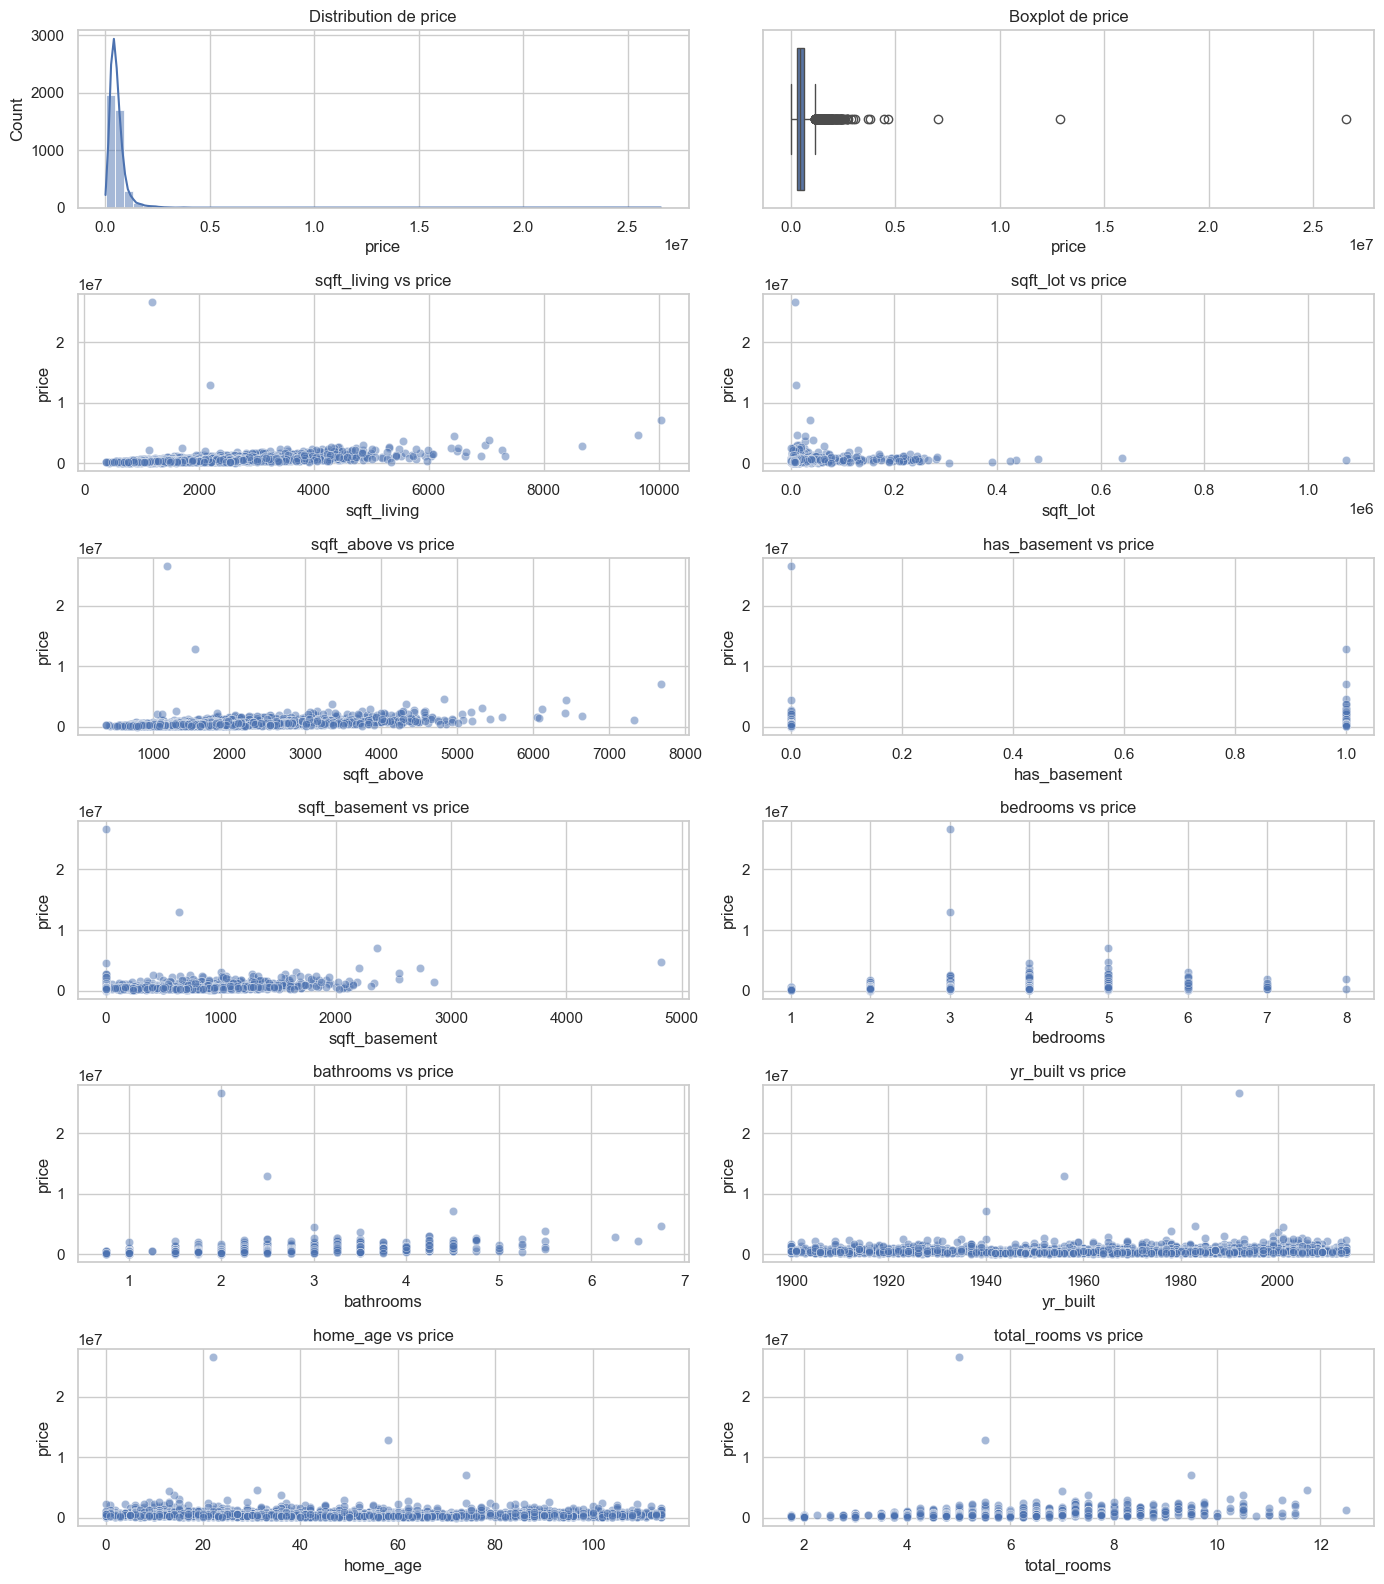

Skewness de price : 25.01


In [31]:
fig, axes = plt.subplots(6, 2, figsize=(14, 16))

sns.histplot(fe_df["price"], bins=60, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution de price")

sns.boxplot(x=fe_df["price"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de price")

sns.scatterplot(data=fe_df, x="sqft_living", y="price", alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("sqft_living vs price")

sns.scatterplot(data=fe_df, x="sqft_lot", y="price", alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title("sqft_lot vs price")

sns.scatterplot(data=fe_df, x="sqft_above", y="price", alpha=0.5, ax=axes[2, 0])
axes[2, 0].set_title("sqft_above vs price")

sns.scatterplot(data=fe_df, x="has_basement", y="price", alpha=0.5, ax=axes[2, 1])
axes[2, 1].set_title("has_basement vs price")

sns.scatterplot(data=fe_df, x="sqft_basement", y="price", alpha=0.5, ax=axes[3, 0])
axes[3, 0].set_title("sqft_basement vs price")

sns.scatterplot(data=fe_df, x="bedrooms", y="price", alpha=0.5, ax=axes[3, 1])
axes[3, 1].set_title("bedrooms vs price")

sns.scatterplot(data=fe_df, x="bathrooms", y="price", alpha=0.5, ax=axes[4, 0])
axes[4, 0].set_title("bathrooms vs price")

sns.scatterplot(data=fe_df, x="yr_built", y="price", alpha=0.5, ax=axes[4, 1])
axes[4, 1].set_title("yr_built vs price")


sns.scatterplot(data=fe_df, x="home_age", y="price", alpha=0.5, ax=axes[5, 0])
axes[5, 0].set_title("home_age vs price")

sns.scatterplot(data=fe_df, x="total_rooms", y="price", alpha=0.5, ax=axes[5, 1])
axes[5, 1].set_title("total_rooms vs price")




plt.tight_layout()
plt.show()

print("Skewness de price :", round(fe_df["price"].skew(), 2))


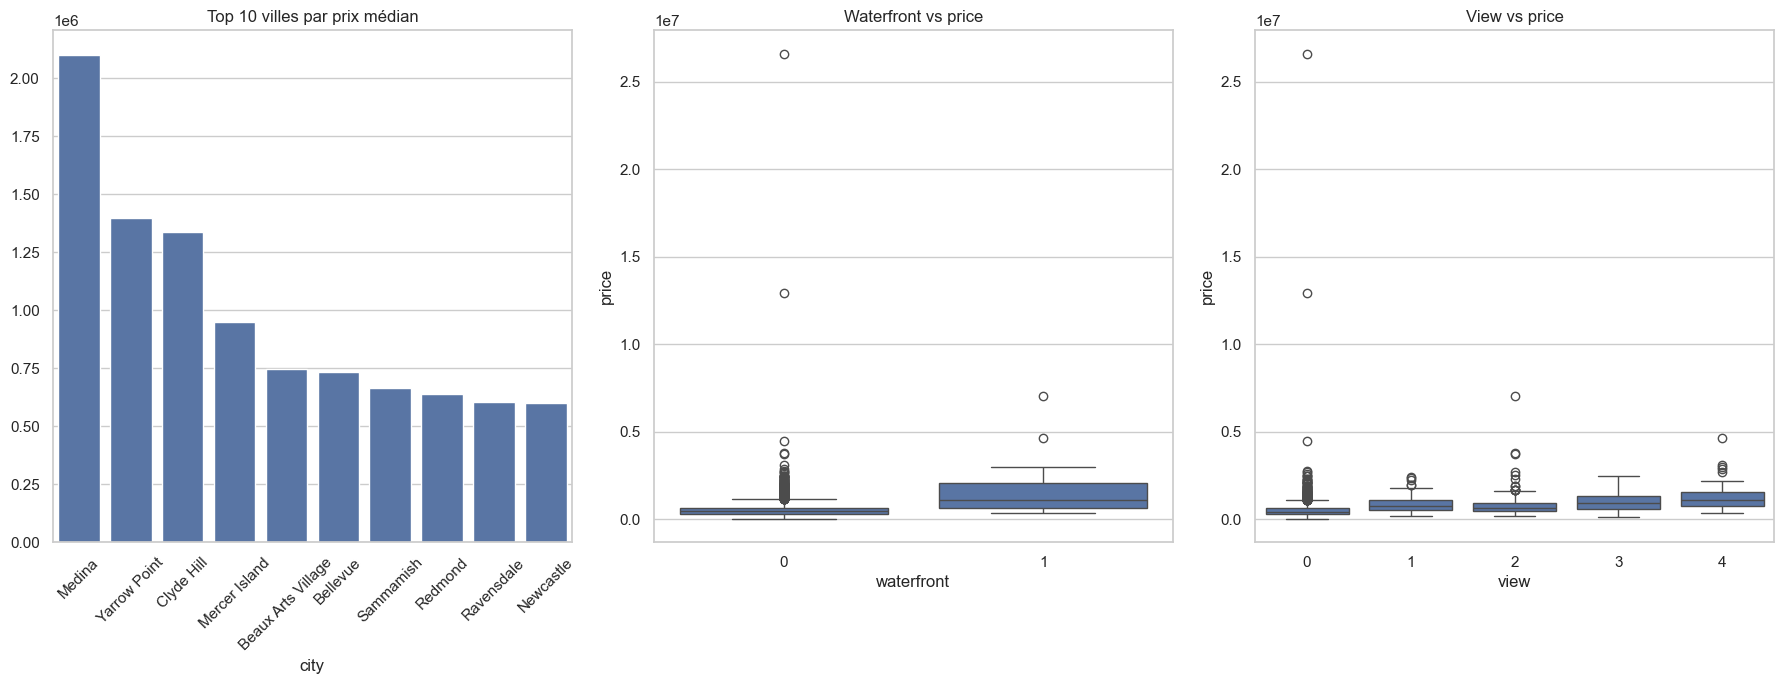

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

city_price = fe_df.groupby("city")["price"].median().sort_values(ascending=False).head(10)
sns.barplot(x=city_price.index, y=city_price.values, ax=axes[0])
axes[0].set_title("Top 10 villes par prix médian")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=fe_df, x="waterfront", y="price", ax=axes[1])
axes[1].set_title("Waterfront vs price")

sns.boxplot(data=fe_df, x="view", y="price", ax=axes[2])
axes[2].set_title("View vs price")

plt.tight_layout()
plt.show()

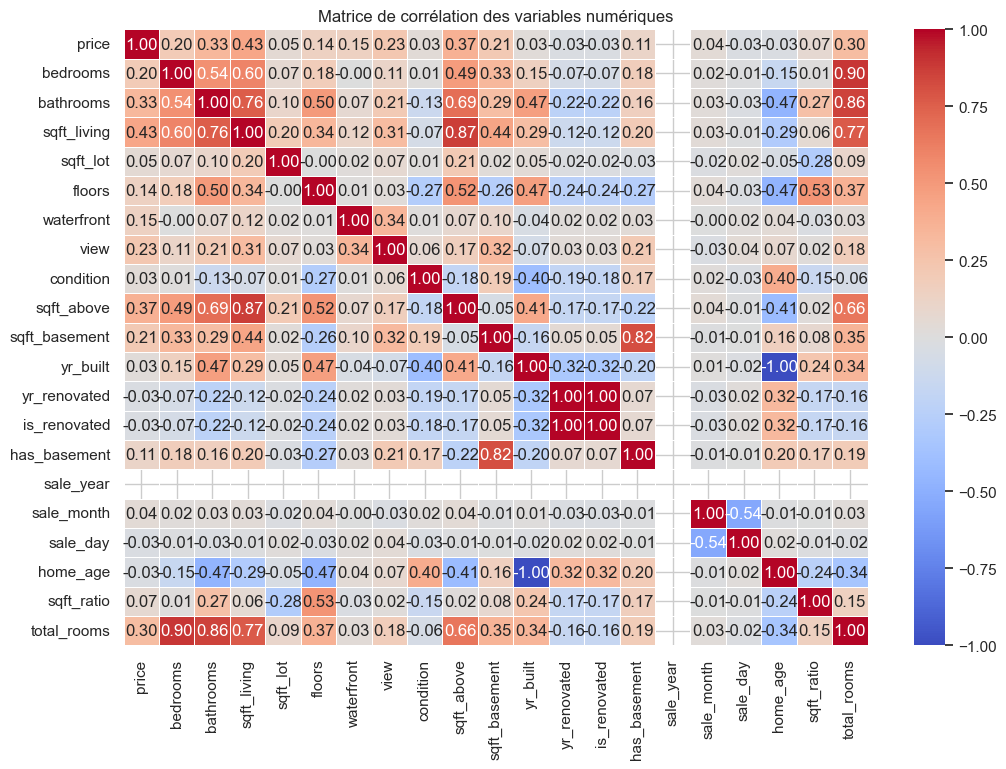

,corr_with_price
price,1.00
sqft_living,0.43
sqft_above,0.37
bathrooms,0.33
total_rooms,0.30
view,0.23
sqft_basement,0.21
bedrooms,0.20
waterfront,0.15
floors,0.14


In [ ]:
num_cols = fe_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
corr = fe_df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0 , annot=True, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

corr_price = corr["price"].sort_values(ascending=False)
display(corr_price.to_frame("corr_with_price"))

## Analyse exploratoire des données (EDA)

L’analyse exploratoire met en évidence que la variable cible `price` présente une **très forte asymétrie à droite**, avec une skewness de **25.01**. La majorité des biens se concentre dans une plage de prix standard, tandis qu’un petit nombre de maisons très haut de gamme étend fortement la distribution. Le boxplot confirme également la présence de nombreux outliers, qui semblent davantage correspondre à des biens exceptionnels qu’à des erreurs évidentes.

Les visualisations montrent que les variables de **surface intérieure** sont les plus liées au prix. En particulier, `sqft_living` apparaît comme la variable numérique la plus informative, suivie de `sqft_above` et `bathrooms`. À l’inverse, `sqft_lot` présente une relation beaucoup plus diffuse avec `price`, ce qui suggère un effet plus indirect et dépendant du contexte.

Les variables de **standing** jouent également un rôle important. Les boxplots montrent que les biens situés en bord de l’eau (`waterfront`) et ceux disposant d’une meilleure vue (`view`) ont des niveaux de prix globalement plus élevés. De plus, l’analyse des prix médians par ville met en évidence un **effet géographique fort**, confirmant que la localisation constitue une dimension essentielle de la valorisation immobilière.

Enfin, la matrice de corrélation met en évidence plusieurs **redondances** entre variables, notamment entre `sqft_living` et `sqft_above`, entre `bedrooms`, `bathrooms` et `total_rooms`, ainsi qu’entre `yr_built` et `home_age`. Ces résultats orientent la suite du projet : conserver les variables les plus informatives, limiter la redondance entre features, et prendre en compte l’asymétrie de la cible dans la phase de modélisation.

In [34]:
fe_df["city"].nunique()

43

In [35]:
fe_df['statezip'].nunique()

77

## 5. Préparation pour la modélisation

On prépare :
- un **jeu de test** séparé ;
- des **pipelines** pour éviter le leakage ;
- un prétraitement différent selon le type de variable.

On utilise ici `log1p(price)` comme cible d'entraînement. C'est très utile quand la distribution du prix est très asymétrique.
Ensuite, on repasse les prédictions sur l'échelle d'origine avec `expm1` pour calculer les métriques business.

In [36]:
fe_df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip', 'is_renovated',
       'has_basement', 'sale_year', 'sale_month', 'sale_day', 'home_age',
       'sqft_ratio', 'total_rooms'],
      dtype='object')

In [37]:
target = "price"
features = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "waterfront", "view", "condition", "sqft_above", "sqft_basement",
    "city", "sale_month","is_renovated","home_age"
]
X = fe_df[features].copy()
y = fe_df[target].copy()

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y,
    test_size=0.2,
    random_state=42
    )
numeric_features = X_train.select_dtypes(include = ["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include = ["object"]).columns.tolist()

print("Features numériques :", numeric_features)
print("Features catégorielles :", categorical_features)
print(f'train shape :{X_train.shape}' )
print(f'test shape :{X_test.shape}' )
                                                                                     

Features numériques : ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'sale_month', 'is_renovated', 'home_age']
Features catégorielles : ['city']
train shape :(3271, 14)
test shape :(818, 14)


## Préparation des données pour la modélisation

La variable cible retenue pour la modélisation est `price`, tandis que les variables explicatives sélectionnées regroupent des informations sur la structure du bien, ses surfaces, son standing, sa localisation et certaines variables issues du feature engineering, comme `is_renovated` et `home_age`.

Étant donné la très forte asymétrie observée sur la distribution de `price`, une transformation logarithmique a été appliquée à la cible via `log1p(price)`. Cette étape permet de réduire l’effet des valeurs extrêmes et de faciliter l’apprentissage pour plusieurs modèles de régression.

Les données ont ensuite été séparées en un jeu d’entraînement (**80 %**) et un jeu de test (**20 %**). La cible transformée (`y_log`) et la cible brute (`y`) sont découpées en même temps afin de conserver un alignement parfait entre les observations, ce qui permettra d’entraîner les modèles sur l’échelle logarithmique tout en évaluant leurs performances finales sur l’échelle réelle des prix.

Enfin, les variables ont été séparées selon leur type en deux groupes distincts : les variables numériques et les variables catégorielles. Cette distinction est nécessaire pour construire ensuite des pipelines de prétraitement adaptés, avec notamment un encodage spécifique pour la variable `city`.

In [39]:
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_linear = ColumnTransformer(transformers=[
    ("num", numeric_preprocessor, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])


## Définition des préprocesseurs

Deux préprocesseurs distincts ont été définis afin d’adapter les transformations au type de modèle utilisé. Pour les variables numériques, un pipeline spécifique est mis en place avec une imputation par la médiane, puis une standardisation via `StandardScaler`. Cette étape est particulièrement importante pour les modèles linéaires comme `Ridge`, qui sont sensibles à l’échelle des variables.

Pour les variables catégorielles, un second pipeline applique une imputation par la modalité la plus fréquente, suivie d’un encodage `OneHotEncoder`. L’option `handle_unknown="ignore"` permet de gérer proprement les catégories non vues pendant l’entraînement, notamment lors de la prédiction ou de la validation croisée.

Ces transformations sont ensuite regroupées dans un `ColumnTransformer`, qui applique automatiquement le bon traitement à chaque groupe de variables. Deux versions sont construites : `preprocessor_linear` pour les modèles linéaires, avec standardisation des variables numériques, et `preprocessor_tree` pour les modèles d’arbres, où seule l’imputation est conservée sur les variables numériques, le scaling n’étant pas nécessaire dans ce cas.

In [40]:
models = {
    "Dummy": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", DummyRegressor(strategy="median"))
    ]),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", Ridge(alpha=10.0))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])
}


## Définition des modèles à comparer

Plusieurs modèles de régression ont été définis afin de comparer différents niveaux de complexité et de flexibilité. Chaque modèle est intégré dans un pipeline complet, incluant à la fois le prétraitement des données et l’algorithme de régression. Cette approche garantit une exécution cohérente et sans fuite de données, aussi bien sur le jeu de test que lors de la validation croisée.

Le modèle `DummyRegressor` sert de baseline minimale. Il prédit systématiquement la médiane de la cible et permet de vérifier que les autres modèles apprennent réellement une relation utile entre les variables explicatives et le prix.

Le modèle `Ridge` constitue une baseline linéaire régularisée. Il est particulièrement adapté lorsque plusieurs variables sont corrélées entre elles et permet d’obtenir un modèle simple, stable et interprétable.

Deux modèles d’arbres sont également testés : `RandomForestRegressor` et `GradientBoostingRegressor`. Le premier repose sur un ensemble d’arbres entraînés en parallèle, tandis que le second construit les arbres de manière séquentielle afin de corriger progressivement les erreurs. Ces modèles permettent de capturer des relations non linéaires et des interactions plus complexes entre les variables.

L’objectif de cette étape est d’évaluer si un modèle simple comme `Ridge` suffit à bien représenter le signal, ou si des modèles plus flexibles permettent d’améliorer significativement les performances prédictives.

In [41]:
def regression_report(y_true_raw, y_pred_raw):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    r2 = r2_score(y_true_raw, y_pred_raw)
    mape = np.mean(np.abs((y_true_raw - y_pred_raw) / y_true_raw)) * 100
    return mae, rmse, r2, mape

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train_log)
    pred_log = model.predict(X_test)
    pred_raw = np.expm1(pred_log)
    pred_raw = np.clip(pred_raw, 0, None)

    mae, rmse, r2, mape = regression_report(y_test_raw, pred_raw)

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_%": mape
    })

    predictions[name] = pred_raw

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
display(results_df)

,model,MAE,RMSE,R2,MAPE_%
3,GradientBoosting,"101,655.26","172,715.61",0.65,21.71
1,Ridge,"102,967.10","182,075.94",0.61,20.72
2,RandomForest,"112,091.53","186,767.72",0.59,22.95
0,Dummy,"198,606.40","297,789.05",-0.04,42.27


## Entraînement des modèles et évaluation sur le jeu de test

Les différents modèles sont entraînés sur le jeu d’entraînement en utilisant la cible transformée `log1p(price)`. Cette transformation permet de mieux gérer l’asymétrie très marquée de la variable cible observée lors de l’analyse exploratoire.

Une fois les prédictions obtenues sur le jeu de test, celles-ci sont retranscrites sur l’échelle réelle des prix grâce à la fonction `expm1`, afin de pouvoir interpréter les performances dans une unité métier cohérente. Une contrainte supplémentaire est appliquée pour éviter toute prédiction négative, ce qui n’aurait pas de sens dans le contexte immobilier.

Quatre métriques sont ensuite calculées pour chaque modèle :
- **MAE** : erreur absolue moyenne, interprétable directement en dollars ;
- **RMSE** : erreur quadratique moyenne, plus sensible aux grosses erreurs ;
- **R²** : proportion de variance du prix expliquée par le modèle ;
- **MAPE** : erreur relative moyenne en pourcentage.

L’objectif de cette étape est de comparer les modèles sur le jeu de test afin d’identifier celui qui offre le meilleur compromis entre précision prédictive et cohérence métier.

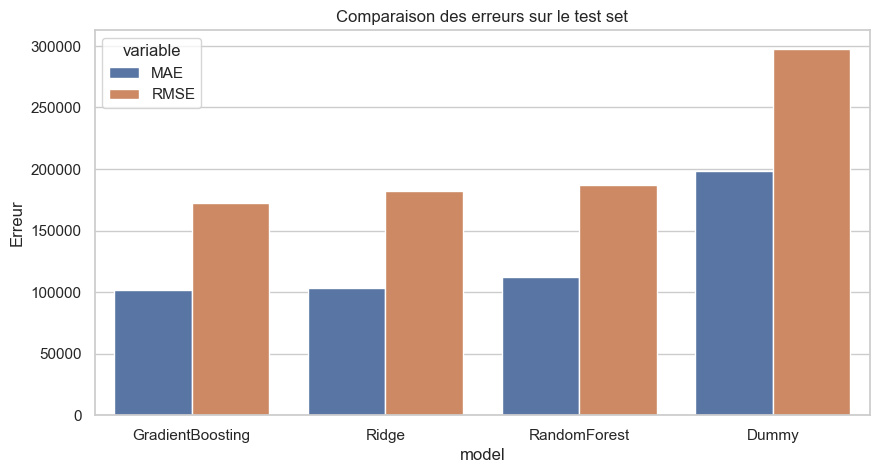

In [42]:
plt.figure(figsize=(10, 5))
plot_df = results_df.melt(id_vars="model", value_vars=["MAE", "RMSE"])
sns.barplot(data=plot_df, x="model", y="value", hue="variable")
plt.title("Comparaison des erreurs sur le test set")
plt.ylabel("Erreur")
plt.show()


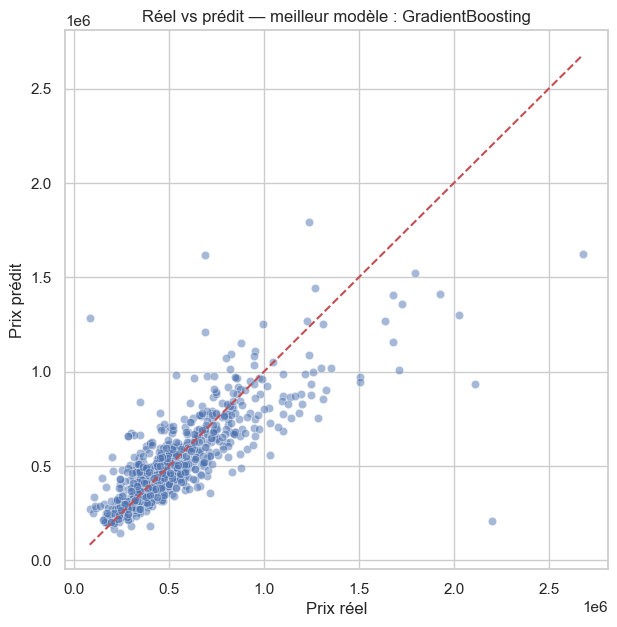

In [43]:
best_model_name = results_df.iloc[0]["model"]
best_preds = predictions[best_model_name]

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test_raw, y=best_preds, alpha=0.5)
plt.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], "r--")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title(f"Réel vs prédit — meilleur modèle : {best_model_name}")
plt.show()

## Visualisation des performances sur le jeu de test

Le graphique comparant la **MAE** et le **RMSE** confirme que le modèle `GradientBoosting` obtient les meilleures performances globales sur le jeu de test. Il présente les erreurs les plus faibles, aussi bien en moyenne absolue qu’en moyenne quadratique, ce qui en fait le meilleur candidat parmi les modèles testés. Le modèle `Ridge` reste toutefois très proche, ce qui montre qu’une part importante du signal est déjà bien captée par une approche linéaire régularisée. À l’inverse, `RandomForest` est légèrement moins performant, tandis que `Dummy` confirme son rôle de baseline minimale avec des erreurs nettement plus élevées.

Le graphique **réel vs prédit** pour le meilleur modèle (`GradientBoosting`) montre que la majorité des prédictions suit correctement la diagonale idéale, ce qui indique une bonne capacité à reproduire la tendance générale du marché. Le modèle semble particulièrement pertinent pour les biens situés dans la zone centrale de la distribution des prix. En revanche, la dispersion augmente pour les prix les plus élevés, ce qui traduit une difficulté plus importante à prédire précisément les biens haut de gamme ou atypiques.

Dans l’ensemble, ces visualisations confirment que le modèle sélectionné capture correctement la structure générale du problème, tout en conservant une marge d’erreur plus marquée sur les observations extrêmes, ce qui reste cohérent avec l’analyse exploratoire de la variable cible.

# cross-validation

In [44]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y_log,
        cv=cv,
        scoring="r2",
        n_jobs=-1,
        return_train_score=True
    )
    cv_rows.append({
        "model": name,
        "cv_r2_mean": scores["test_score"].mean(),
        "cv_r2_std": scores["test_score"].std(),
        "train_r2_mean": scores["train_score"].mean(),
        "gap_train_cv": scores["train_score"].mean() - scores["test_score"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by="cv_r2_mean", ascending=False)
display(cv_results_df)


,model,cv_r2_mean,cv_r2_std,train_r2_mean,gap_train_cv
1,Ridge,0.70,0.04,0.71,0.01
3,GradientBoosting,0.69,0.05,0.79,0.09
2,RandomForest,0.67,0.05,0.84,0.16
0,Dummy,-0.00,0.00,-0.00,0.00


## Interprétation de la validation croisée

La validation croisée à 5 folds montre que le modèle **Ridge** obtient la meilleure performance moyenne en validation (`cv_r2_mean = 0.70`) avec une faible variabilité entre les folds (`cv_r2_std = 0.04`) et un écart très faible entre le score d’entraînement et le score de validation (`gap_train_cv = 0.01`). Cela indique un modèle très stable, peu sensible aux variations de l’échantillon d’apprentissage et présentant un risque très limité de surapprentissage.

Le modèle **GradientBoosting** affiche une performance moyenne très proche (`cv_r2_mean = 0.69`) mais avec un score d’entraînement plus élevé et un écart train-validation plus marqué (`gap_train_cv = 0.09`). Cela suggère un léger surapprentissage, qui reste toutefois modéré et acceptable. Ce comportement est cohérent avec les résultats observés sur le jeu de test, où `GradientBoosting` obtenait les meilleures métriques globales.

À l’inverse, **RandomForest** présente un écart plus important entre les scores d’entraînement et de validation (`gap_train_cv = 0.16`), ce qui traduit un surapprentissage plus net. Enfin, le modèle **Dummy** confirme son rôle de baseline minimale avec des performances nulles.

Dans l’ensemble, ces résultats montrent que **Ridge** est le modèle le plus stable et le plus robuste, tandis que **GradientBoosting** constitue le meilleur choix en termes de performance prédictive finale sur le jeu de test.

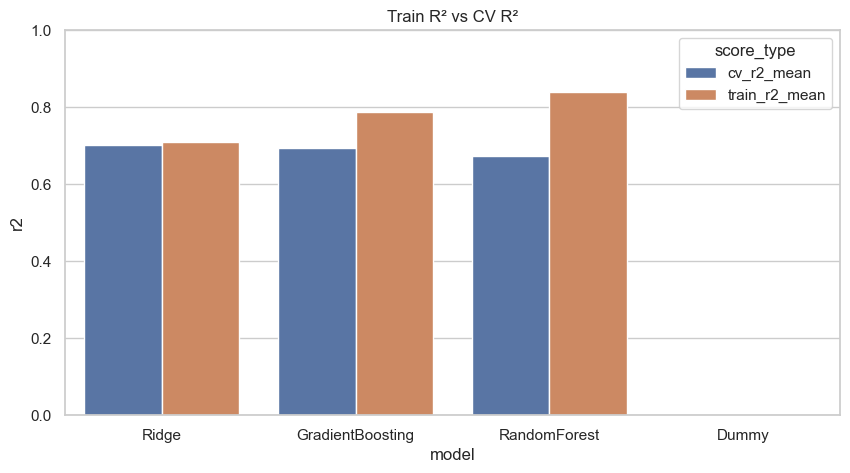

In [45]:
plt.figure(figsize=(10, 5))
plot_df = cv_results_df.melt(
    id_vars="model",
    value_vars=["cv_r2_mean", "train_r2_mean"],
    var_name="score_type",
    value_name="r2"
)
sns.barplot(data=plot_df, x="model", y="r2", hue="score_type")
plt.title("Train R² vs CV R²")
plt.ylim(0, 1)
plt.show()


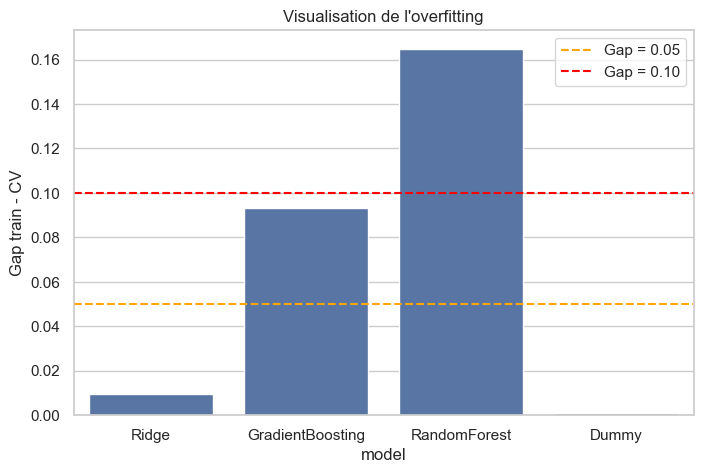

In [47]:
plot_df = cv_results_df.copy()

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="model", y="gap_train_cv")
plt.axhline(0.05, color="orange", linestyle="--", label="Gap = 0.05")
plt.axhline(0.10, color="red", linestyle="--", label="Gap = 0.10")
plt.ylabel("Gap train - CV")
plt.title("Visualisation de l'overfitting")
plt.legend()
plt.show()

## Visualisation du surapprentissage

Le graphique du `gap_train_cv` permet de visualiser directement le niveau de surapprentissage de chaque modèle. Cet indicateur correspond à la différence entre la performance moyenne sur les folds d’entraînement et la performance moyenne sur les folds de validation croisée. Plus cet écart est élevé, plus le modèle risque d’être trop ajusté aux données d’entraînement.

Le modèle **Ridge** présente un gap très faible, proche de zéro, ce qui confirme son excellente capacité de généralisation. Il s’agit du modèle le plus stable et le moins sujet au surapprentissage parmi ceux testés.

Le modèle **GradientBoosting** montre un écart plus visible, mais qui reste inférieur au seuil de surapprentissage fort. Cela suggère un léger overfitting, cohérent avec son niveau de complexité plus élevé, tout en restant acceptable compte tenu de ses bonnes performances sur le jeu de test.

En revanche, **RandomForest** dépasse nettement le seuil d’alerte, avec un gap supérieur à 0.10. Cela traduit un surapprentissage plus marqué : le modèle apprend bien les données d’entraînement, mais sa performance se dégrade davantage lorsqu’il est évalué sur des données non vues.

Dans l’ensemble, ce graphique confirme que **Ridge** est le modèle le plus robuste, tandis que **GradientBoosting** constitue un bon compromis entre performance prédictive et complexité.

In [48]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


Skewness de sqft_living : 1.44


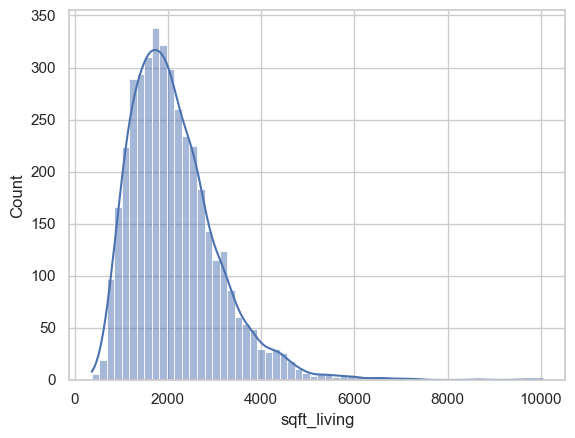

In [52]:
sns.histplot(fe_df["sqft_living"], bins=60, kde=True)
print("Skewness de sqft_living :", round(fe_df["sqft_living"].skew(), 2))

Skewness de sqft_lot : 11.81


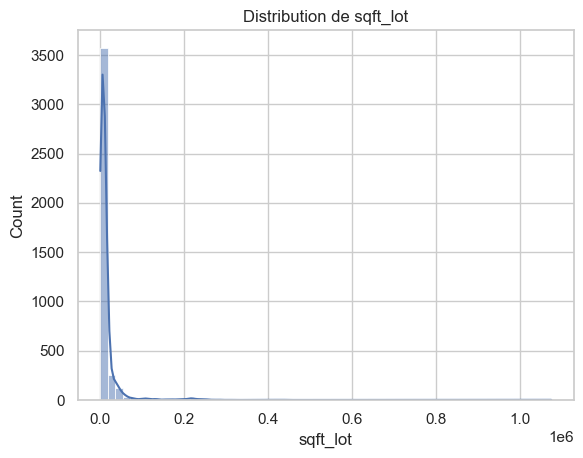

In [53]:
sns.histplot(fe_df["sqft_lot"], bins=60, kde=True)
plt.title("Distribution de sqft_lot")
print("Skewness de sqft_lot :", round(fe_df["sqft_lot"].skew(), 2))

In [54]:
fe_df2["log_sqft_living"] = np.log1p(fe_df2["sqft_living"])
fe_df2["log_sqft_lot"]    = np.log1p(fe_df2["sqft_lot"])

Skewness de log_sqft_living : -0.08


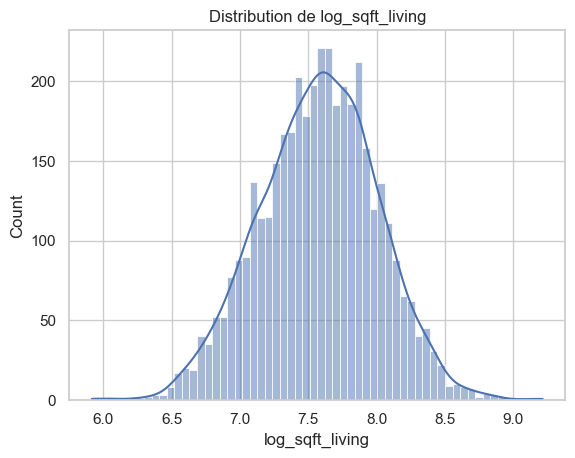

Skewness de log_sqft_lot : 0.85


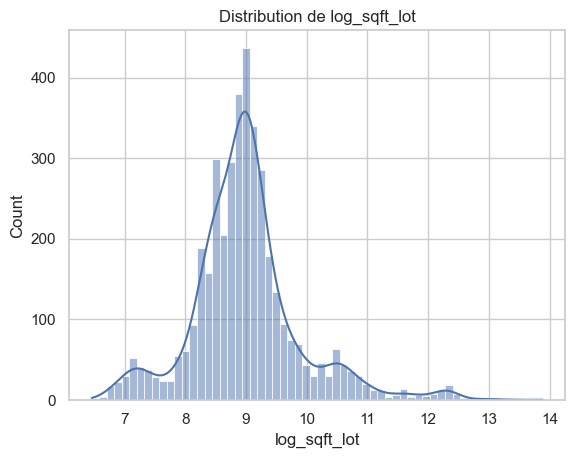

In [55]:
list_log_cols = ["log_sqft_living", "log_sqft_lot"]
for col in list_log_cols:
    sns.histplot(fe_df2[col], bins=60, kde=True)
    plt.title(f"Distribution de {col}")
    print(f"Skewness de {col} :", round(fe_df2[col].skew(), 2))
    plt.show()

In [ ]:
fe_df2 = fe_df.copy()

In [57]:
fe_df2["bath_bed_ratio"] = fe_df2["bathrooms"] / fe_df2["bedrooms"].clip(lower=1)
fe_df2["living_x_view"] = fe_df2["sqft_living"] * fe_df2["view"]
fe_df2["living_x_waterfront"] = fe_df2["sqft_living"] * fe_df2["waterfront"]
fe_df2['living_x_condition'] = fe_df2["sqft_living"] * fe_df2["condition"]

In [58]:
fe_df2["home_age_sq"] = fe_df2["home_age"] ** 2
fe_df2["quality_score"] = fe_df2["view"] + fe_df2["condition"] + fe_df2["waterfront"] * 3

In [59]:
print(f"Shape avec nouvelles features : {fe_df2.shape}")
print("Nouvelles colonnes ajoutées :")
new_cols = ["bath_bed_ratio", "living_x_view", "living_x_waterfront",
            "living_x_condition", "log_sqft_living", "log_sqft_lot",
            "home_age_sq", "quality_score"]
print(new_cols)

Shape avec nouvelles features : (4089, 31)
Nouvelles colonnes ajoutées :
['bath_bed_ratio', 'living_x_view', 'living_x_waterfront', 'living_x_condition', 'log_sqft_living', 'log_sqft_lot', 'home_age_sq', 'quality_score']


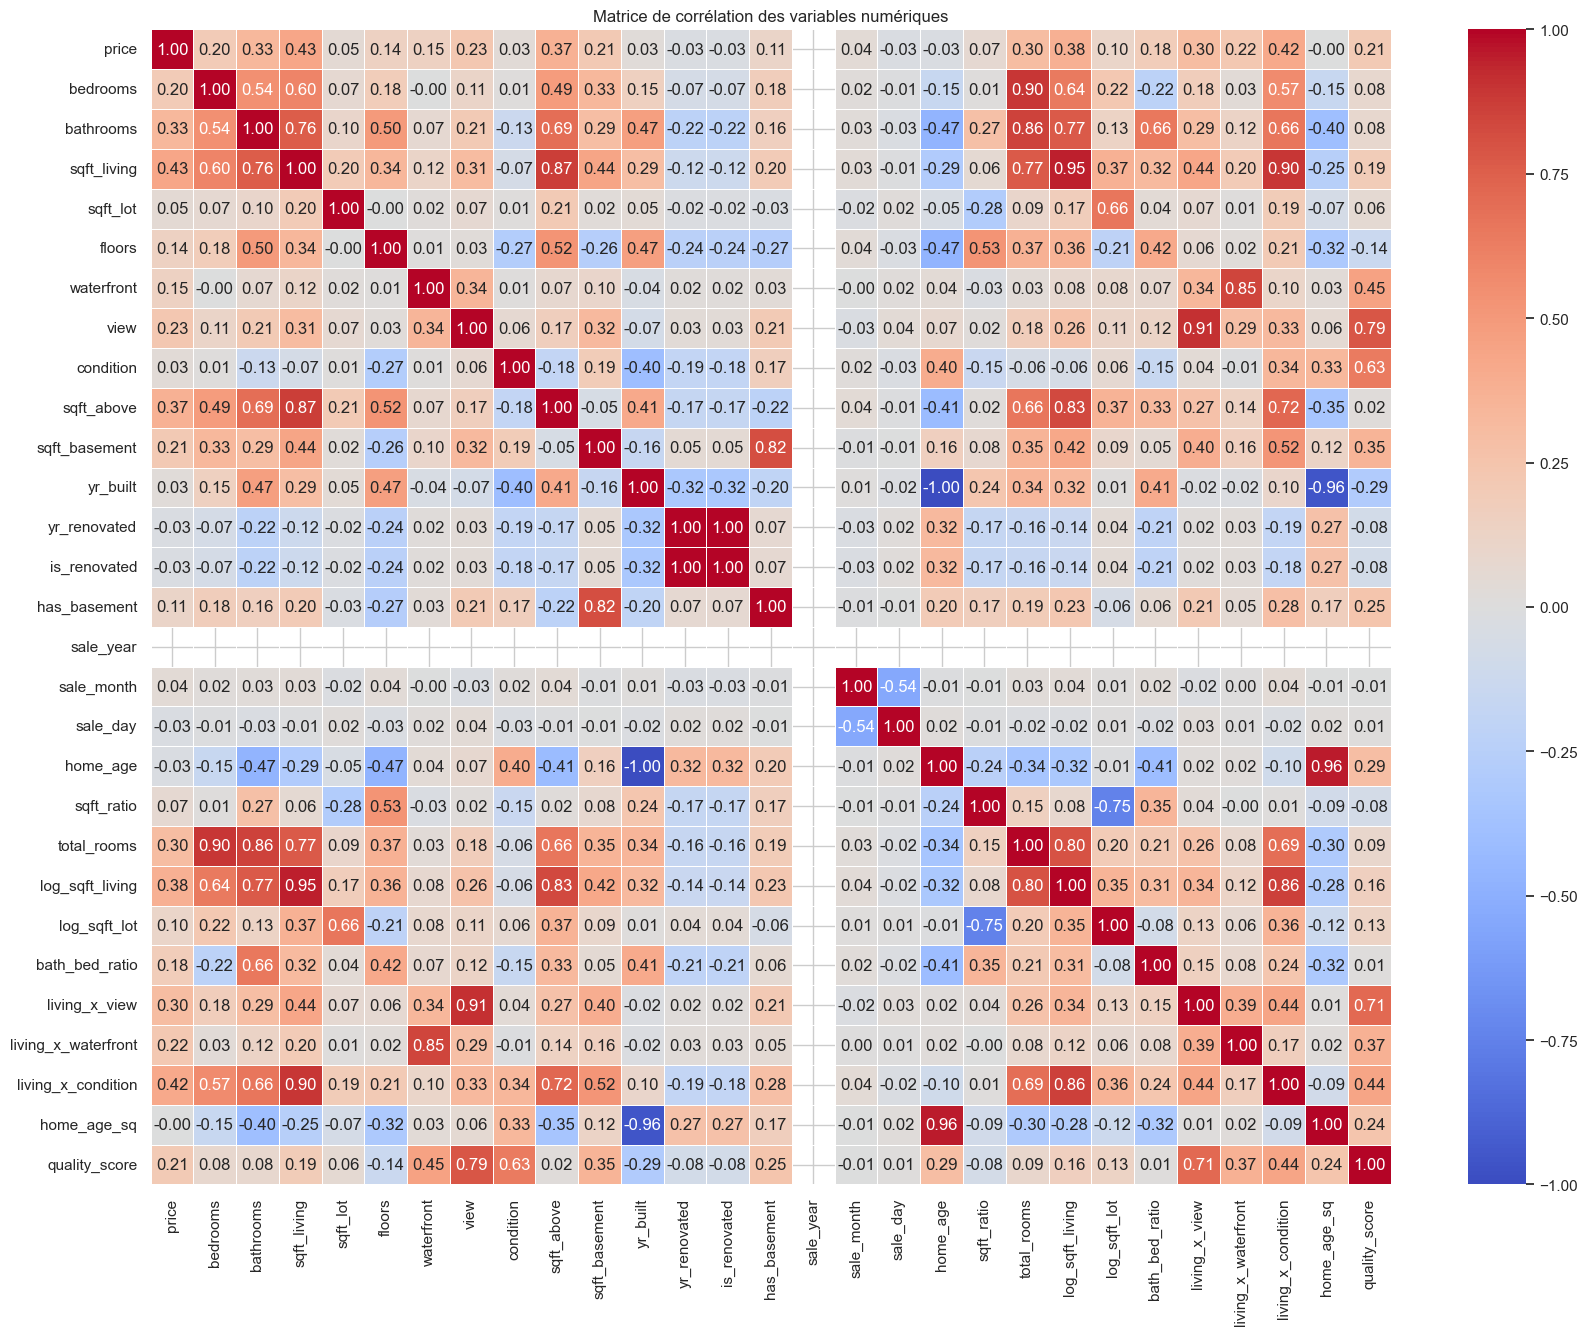

,corr_with_price
price,1.00
sqft_living,0.43
living_x_condition,0.42
log_sqft_living,0.38
sqft_above,0.37
bathrooms,0.33
living_x_view,0.30
total_rooms,0.30
view,0.23
living_x_waterfront,0.22


In [62]:
num_cols = fe_df2.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
corr = fe_df2[num_cols].corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0 , annot=True, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

corr_price = corr["price"].sort_values(ascending=False)
display(corr_price.to_frame("corr_with_price"))

In [71]:
features_v2 = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_basement",
    'sqft_above',
    "city",
    "sale_month",
    "is_renovated",
    "home_age",
    "bath_bed_ratio",
    "living_x_view",
    "living_x_waterfront",
    "living_x_condition",
    "log_sqft_living",
    "log_sqft_lot",
    "quality_score"
]

target = "price"

X2 = fe_df2[features_v2].copy()
y2 = fe_df2[target].copy()
y2_log = np.log1p(y2)

X2_train, X2_test, y2_train_log, y2_test_log, y2_train_raw, y2_test_raw = train_test_split(
    X2, y2_log, y2, test_size=0.2, random_state=42)

numeric_features_v2 = X2_train.select_dtypes(include = ["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features_v2 = X2_train.select_dtypes(include = ["object"]).columns.tolist()
print(f"Train : {X2_train.shape} | Test : {X2_test.shape}")
print(f"Features numériques  : {len(numeric_features_v2)}")
print(f"Features catégorielles : {len(categorical_features_v2)}")


Train : (3271, 21) | Test : (818, 21)
Features numériques  : 20
Features catégorielles : 1


In [72]:
numeric_preprocessor_v2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler())
])
categorical_preprocessor_v2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_linear_v2 = ColumnTransformer(transformers=[
    ("num", numeric_preprocessor_v2, numeric_features_v2),
    ("cat", categorical_preprocessor_v2, categorical_features_v2)
])
preprocessor_tree_v2 = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_features_v2),
    ("cat", categorical_preprocessor_v2, categorical_features_v2)
])


In [73]:
models_v2 = {

    
    "Ridge_v2": Pipeline([
        ("preprocessor", preprocessor_linear_v2),
        ("model", __import__("sklearn.linear_model", fromlist=["Ridge"]).Ridge(alpha=10.0))
    ]),

    
    "GradientBoosting_v2": Pipeline([
        ("preprocessor", preprocessor_tree_v2),
        ("model", __import__("sklearn.ensemble", fromlist=["GradientBoostingRegressor"])
                  .GradientBoostingRegressor(
                      n_estimators=500,
                      learning_rate=0.03,   
                      max_depth=3,
                      subsample=0.8,       
                      min_samples_leaf=5,
                      random_state=42
                  ))
    ]),

    
    "RandomForest_v2": Pipeline([
        ("preprocessor", preprocessor_tree_v2),
        ("model", __import__("sklearn.ensemble", fromlist=["RandomForestRegressor"])
                  .RandomForestRegressor(
                      n_estimators=300,
                      max_depth=8,           
                      min_samples_leaf=10,   
                      max_features=0.6,
                      random_state=42,
                      n_jobs=-1
                  ))
    ]),

   
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_tree_v2),
        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0
        ))
    ]),

    
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor_tree_v2),
        ("model", LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbose=-1
        ))
    ]),
}


In [74]:
def regression_report(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, r2, mape

results_v2   = []
predictions_v2 = {}

for name, model in models_v2.items():
    print(f" Entraînement : {name}...")
    model.fit(X2_train, y2_train_log)

    pred_log = model.predict(X2_test)
    pred_raw = np.clip(np.expm1(pred_log), 0, None)

    mae, rmse, r2, mape = regression_report(y2_test_raw, pred_raw)
    results_v2.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape})
    predictions_v2[name] = pred_raw

results_v2_df = pd.DataFrame(results_v2).sort_values("R2", ascending=False)
print("\n Résultats sur le test set :")
display(results_v2_df)

 Entraînement : Ridge_v2...
 Entraînement : GradientBoosting_v2...
 Entraînement : RandomForest_v2...
 Entraînement : XGBoost...
 Entraînement : LightGBM...

 Résultats sur le test set :


,model,MAE,RMSE,R2,MAPE_%
0,Ridge_v2,"98,448.46","166,663.32",0.67,20.46
1,GradientBoosting_v2,"100,867.45","168,466.26",0.67,20.74
3,XGBoost,"100,654.55","177,269.07",0.63,21.60
4,LightGBM,"104,173.67","186,069.25",0.59,21.30
2,RandomForest_v2,"123,043.19","194,354.66",0.56,25.46


In [75]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows_v2 = []

for name, model in models_v2.items():
    scores = cross_validate(
        model, X2, y2_log,
        cv=cv, scoring="r2",
        n_jobs=-1, return_train_score=True
    )
    cv_rows_v2.append({
        "model":        name,
        "cv_r2_mean":   scores["test_score"].mean(),
        "cv_r2_std":    scores["test_score"].std(),
        "train_r2_mean": scores["train_score"].mean(),
        "gap_train_cv": scores["train_score"].mean() - scores["test_score"].mean()
    })

cv_results_v2_df = pd.DataFrame(cv_rows_v2).sort_values("cv_r2_mean", ascending=False)
print(" Résultats cross-validation :")
display(cv_results_v2_df)

 Résultats cross-validation :


,model,cv_r2_mean,cv_r2_std,train_r2_mean,gap_train_cv
0,Ridge_v2,0.71,0.04,0.73,0.01
1,GradientBoosting_v2,0.71,0.04,0.78,0.07
3,XGBoost,0.70,0.05,0.91,0.20
4,LightGBM,0.70,0.04,0.92,0.23
2,RandomForest_v2,0.63,0.04,0.71,0.08


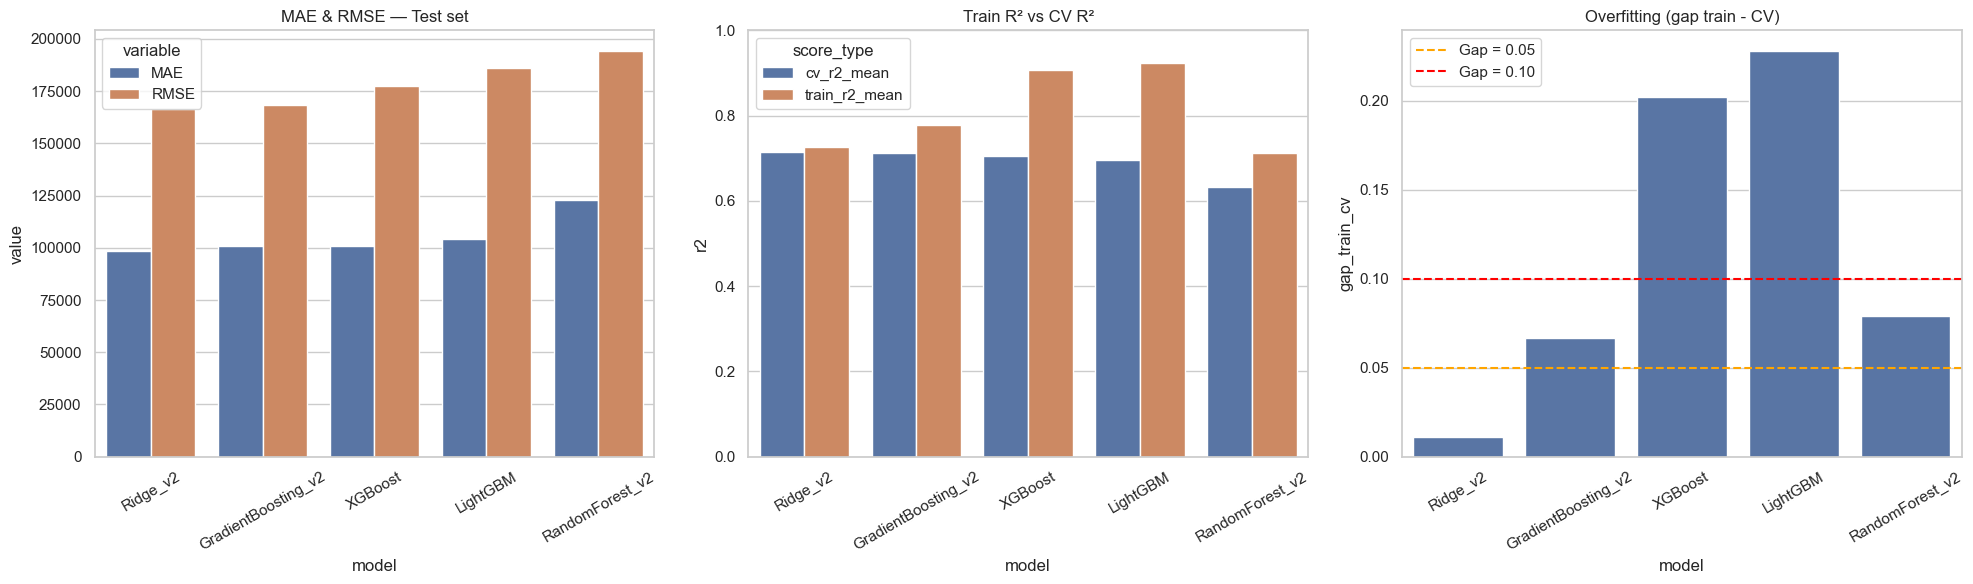

Graphique sauvegardé : comparaison_modeles_finaux.png


In [76]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 7a. MAE / RMSE ---
plot_err = results_v2_df.melt(id_vars="model", value_vars=["MAE", "RMSE"])
sns.barplot(data=plot_err, x="model", y="value", hue="variable", ax=axes[0])
axes[0].set_title("MAE & RMSE — Test set")
axes[0].tick_params(axis="x", rotation=30)

# --- 7b. R² train vs CV ---
plot_cv = cv_results_v2_df.melt(
    id_vars="model",
    value_vars=["cv_r2_mean", "train_r2_mean"],
    var_name="score_type", value_name="r2"
)
sns.barplot(data=plot_cv, x="model", y="r2", hue="score_type", ax=axes[1])
axes[1].set_title("Train R² vs CV R²")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)

# --- 7c. Gap overfitting ---
sns.barplot(data=cv_results_v2_df, x="model", y="gap_train_cv", ax=axes[2])
axes[2].axhline(0.05, color="orange", linestyle="--", label="Gap = 0.05")
axes[2].axhline(0.10, color="red",    linestyle="--", label="Gap = 0.10")
axes[2].set_title("Overfitting (gap train - CV)")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("comparaison_modeles_finaux.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : comparaison_modeles_finaux.png")

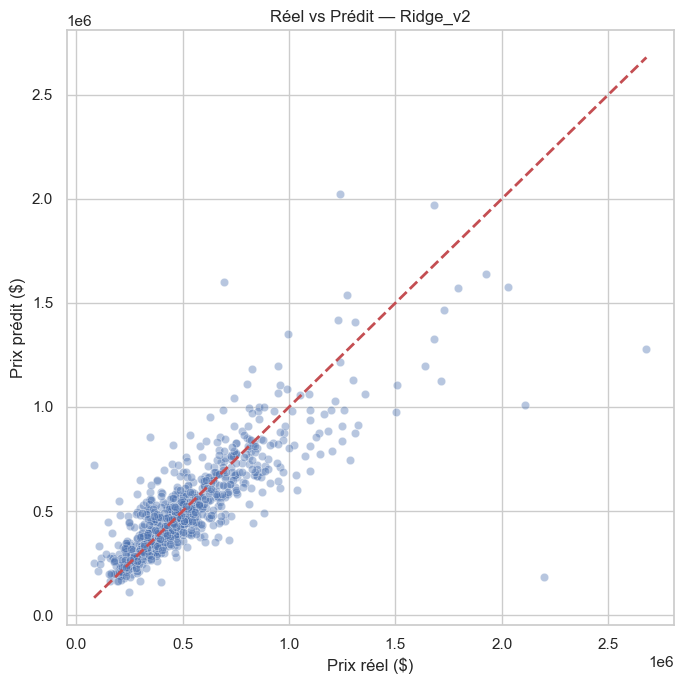

Meilleur modèle : Ridge_v2


In [77]:
best_name_v2 = results_v2_df.iloc[0]["model"]
best_preds_v2 = predictions_v2[best_name_v2]

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y2_test_raw, y=best_preds_v2, alpha=0.4)
plt.plot(
    [y2_test_raw.min(), y2_test_raw.max()],
    [y2_test_raw.min(), y2_test_raw.max()],
    "r--", linewidth=2
)
plt.xlabel("Prix réel ($)")
plt.ylabel("Prix prédit ($)")
plt.title(f"Réel vs Prédit — {best_name_v2}")
plt.tight_layout()
plt.savefig("reel_vs_predit_final.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Meilleur modèle : {best_name_v2}")

In [79]:
best_pipeline = models_v2[best_name_v2]

# On récupère le modèle final entraîné dans le pipeline
final_model = best_pipeline.named_steps["model"]

try:
    importances = final_model.feature_importances_
    # Noms des features après ColumnTransformer
    preprocessor = best_pipeline.named_steps["preprocessor"]
    num_names = numeric_features_v2
    cat_names = preprocessor.named_transformers_["cat"] \
                            .named_steps["onehot"] \
                            .get_feature_names_out(categorical_features_v2).tolist()
    feature_names = num_names + cat_names

    # Garder uniquement les top 20
    importance_df = pd.DataFrame({
        "feature":    feature_names[:len(importances)],
        "importance": importances
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(f"Top 20 features — {best_name_v2}")
    plt.tight_layout()
    plt.savefig("feature_importance_final.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Importance des features sauvegardée.")
except Exception as e:
    print(f"  Importance non disponible pour ce modèle : {e}")


# %%
# ------------------------------------------------------------
# 10. Tableau récapitulatif final
# ------------------------------------------------------------
print("\n" + "="*65)
print("       TABLEAU RÉCAPITULATIF FINAL (test set)")
print("="*65)
display(results_v2_df.style
    .highlight_max(subset=["R2"], color="#c6efce")
    .highlight_min(subset=["MAE", "RMSE", "MAPE_%"], color="#c6efce")
    .format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.3f}", "MAPE_%": "{:.2f}%"})
)

print("\n" + "="*65)
print("       TABLEAU RÉCAPITULATIF FINAL (cross-validation)")
print("="*65)
display(cv_results_v2_df.style
    .highlight_max(subset=["cv_r2_mean"], color="#c6efce")
    .highlight_min(subset=["gap_train_cv"], color="#c6efce")
    .format({
        "cv_r2_mean": "{:.3f}", "cv_r2_std": "{:.3f}",
        "train_r2_mean": "{:.3f}", "gap_train_cv": "{:.3f}"
    })
)


  Importance non disponible pour ce modèle : 'Ridge' object has no attribute 'feature_importances_'

       TABLEAU RÉCAPITULATIF FINAL (test set)


,model,MAE,RMSE,R2,MAPE_%
0,Ridge_v2,"98,448","166,663",0.674,20.46%
1,GradientBoosting_v2,"100,867","168,466",0.667,20.74%
3,XGBoost,"100,655","177,269",0.631,21.60%
4,LightGBM,"104,174","186,069",0.594,21.30%
2,RandomForest_v2,"123,043","194,355",0.557,25.46%



       TABLEAU RÉCAPITULATIF FINAL (cross-validation)


,model,cv_r2_mean,cv_r2_std,train_r2_mean,gap_train_cv
0,Ridge_v2,0.715,0.042,0.726,0.011
1,GradientBoosting_v2,0.712,0.043,0.779,0.067
3,XGBoost,0.705,0.051,0.907,0.202
4,LightGBM,0.696,0.044,0.924,0.228
2,RandomForest_v2,0.633,0.044,0.712,0.079
